
# EV Charging Station Availability Prediction
Dataset:
https://www.kaggle.com/datasets/likithagedipudi/ev-charging-station-availability-tracking


In [2]:

# Install required libraries
!pip install xgboost shap imbalanced-learn openpyxl


   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.8/101.7 MB 7.7 MB/s eta 0:00:14
   - -------------------------------------- 2.6/101.7 MB 8.4 MB/s eta 0:00:12
   - -------------------------------------- 4.7/101.7 MB 9.2 MB/s eta 0:00:11
   -- ------------------------------------- 7.3/101.7 MB 10.1 MB/s eta 0:00:10
   --- ------------------------------------ 9.4/101.7 MB 10.0 MB/s eta 0:00:10
   ----- ---------------------------------- 13.1/101.7 MB 11.4 MB/s eta 0:00:08
   ------- -------------------------------- 18.1/101.7 MB 13.2 MB/s eta 0:00:07
   --------- ------------------------------ 23.1/101.7 MB 14.6 MB/s eta 0:00:06
   ----------- ---------------------------- 28.0/101.7 MB 15.7 MB/s eta 0:00:05
   ------------ --------------------------- 32.8/101.7 MB 16.4 MB/s eta 0:00:05
   --------------- ------------------------ 39.1/101.7 MB 17.7 MB/s eta 0:00:04
   ----------------- ---------------------- 44.3/101.7 MB


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')


In [5]:

# Load Dataset

# Replace with your Kaggle dataset file name
file_path = ('ev_charging_station_data.csv')

df = pd.read_csv(file_path)

print(df.shape)
df.head()


(1317750, 33)


,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,2025-07-01 00:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,5.08,2,none,False,False,0,1,7
1,2025-07-01 00:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.72,3,none,False,False,0,1,7
2,2025-07-01 01:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,partly_cloudy,4.68,1,none,False,False,1,1,7
3,2025-07-01 01:30:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.78,3,none,False,False,1,1,7
4,2025-07-01 02:00:00,EV00001,ChargePoint - Los Angeles #1,ChargePoint,Los Angeles,CA,34.012362,-118.114786,Shopping Center,DC Fast Charge,...,0.0,extreme_heat,4.69,1,none,False,False,2,1,7


In [6]:

# Basic Information

print(df.info())

print(df.describe())

print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 1317750 entries, 0 to 1317749
Data columns (total 33 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   timestamp                  1317750 non-null  str    
 1   station_id                 1317750 non-null  str    
 2   station_name               1317750 non-null  str    
 3   network                    1317750 non-null  str    
 4   city                       1317750 non-null  str    
 5   state                      1317750 non-null  str    
 6   latitude                   1317750 non-null  float64
 7   longitude                  1317750 non-null  float64
 8   location_type              1317750 non-null  str    
 9   charger_type               1317750 non-null  str    
 10  power_output_kw            1317750 non-null  float64
 11  amenities_nearby           1317750 non-null  str    
 12  ports_total                1317750 non-null  int64  
 13  ports_available        

In [7]:

# Data Cleaning

df = df.drop_duplicates()

# Fill missing numerical values
numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values
categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.isnull().sum().sum())


0


In [8]:

# Encode Categorical Variables

label_encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

df.head()


,timestamp,station_id,station_name,network,city,state,latitude,longitude,location_type,charger_type,...,precipitation_mm,weather_condition,gas_price_per_gallon,traffic_congestion_index,local_event,is_weekend,is_peak_hour,hour_of_day,day_of_week,month
0,0,0,29,1,6,1,34.012362,-118.114786,4,0,...,0.0,2,5.08,2,3,False,False,0,1,7
1,1,0,29,1,6,1,34.012362,-118.114786,4,0,...,0.0,6,4.72,3,3,False,False,0,1,7
2,2,0,29,1,6,1,34.012362,-118.114786,4,0,...,0.0,6,4.68,1,3,False,False,1,1,7
3,3,0,29,1,6,1,34.012362,-118.114786,4,0,...,0.0,2,4.78,3,3,False,False,1,1,7
4,4,0,29,1,6,1,34.012362,-118.114786,4,0,...,0.0,2,4.69,1,3,False,False,2,1,7


In [12]:

# Define Target Variable

target_column = 'station_status'

# Create Features and Target
X = df.drop(columns=[target_column])
y = df[target_column]

print(X.shape)
print(y.shape)


(1317750, 32)
(1317750,)


In [13]:

# Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)


(1054200, 32)
(263550, 32)


In [14]:

# Feature Scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [18]:
print(df['station_status'].value_counts())

station_status
1    1162680
0      51886
3      51701
2      51483
Name: count, dtype: int64



# RQ1 — Baseline Performance


Starting RQ1...
Sample created
Target distribution:
station_status
1    17693
0      797
3      760
2      750
Name: count, dtype: int64
Train-test split completed
Scaling completed
Training Logistic Regression...
Logistic Regression completed
Training Decision Tree...
Decision Tree completed
Training Naive Bayes...
Naive Bayes completed

Final Results:
                 Model  Accuracy  Precision   Recall        F1
0  Logistic Regression   0.97275   0.972886  0.97275  0.971474
1        Decision Tree   0.97450   0.975302  0.97450  0.972872
2          Naive Bayes   0.97000   0.971702  0.97000  0.967430


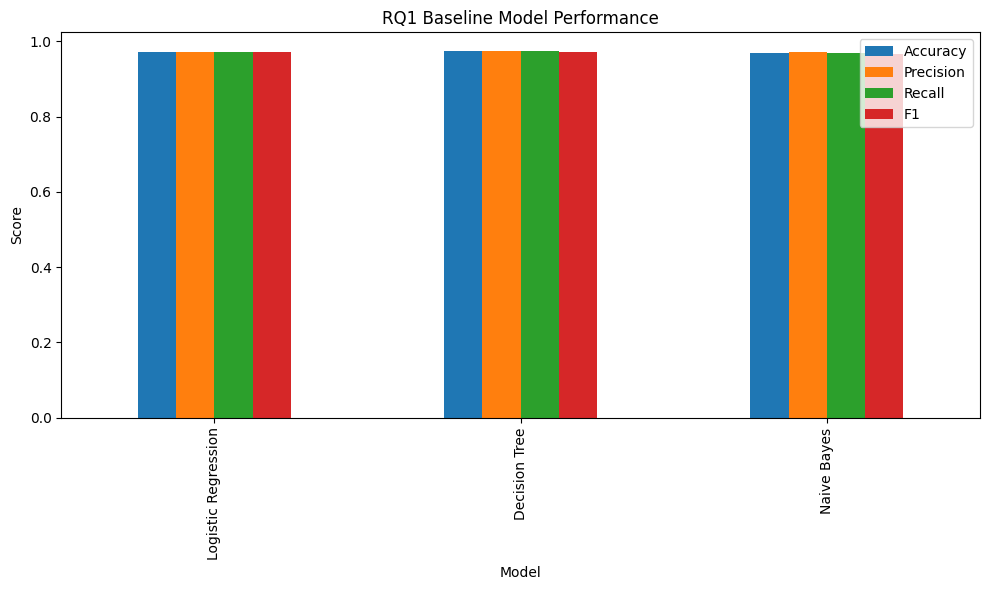

RQ1 Completed Successfully


In [19]:
# ============================================
# RQ1 — Correct Version
# ============================================

print("Starting RQ1...")

# Use smaller sample
df_sample = df.sample(n=20000, random_state=42)

print("Sample created")

# Define Features and Target
X = df_sample.drop(columns=['station_status'])
y = df_sample['station_status']

print("Target distribution:")
print(y.value_counts())

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed")

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Scaling completed")

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=100),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),
    'Naive Bayes': GaussianNB()
}

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

# Train Models
for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    results.append([name, acc, prec, rec, f1])

    print(f"{name} completed")

# Results Table
baseline_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
)

print("\nFinal Results:")
print(baseline_df)

# Save CSV
baseline_df.to_csv('RQ1_Baseline_Table.csv', index=False)

# Plot Figure
import matplotlib.pyplot as plt

baseline_df.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('RQ1 Baseline Model Performance')
plt.ylabel('Score')

plt.tight_layout()

plt.savefig('RQ1_Baseline_Figure.pdf')

plt.show()

print("RQ1 Completed Successfully")


# RQ2 — Model Comparison


Starting RQ2...
Sample created
Target distribution:
station_status
1    26571
0     1177
2     1126
3     1126
Name: count, dtype: int64
Train-test split completed
Scaling completed
Training Logistic Regression...
Logistic Regression completed
Training Decision Tree...
Decision Tree completed
Training Random Forest...
Random Forest completed
Training Naive Bayes...
Naive Bayes completed

Final Results:
                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.973833   0.977682  0.973833  0.971940
1        Decision Tree  0.970833   0.974056  0.970833  0.968263
2        Random Forest  0.970667   0.972509  0.970667  0.967692
3          Naive Bayes  0.969167   0.972466  0.969167  0.965851


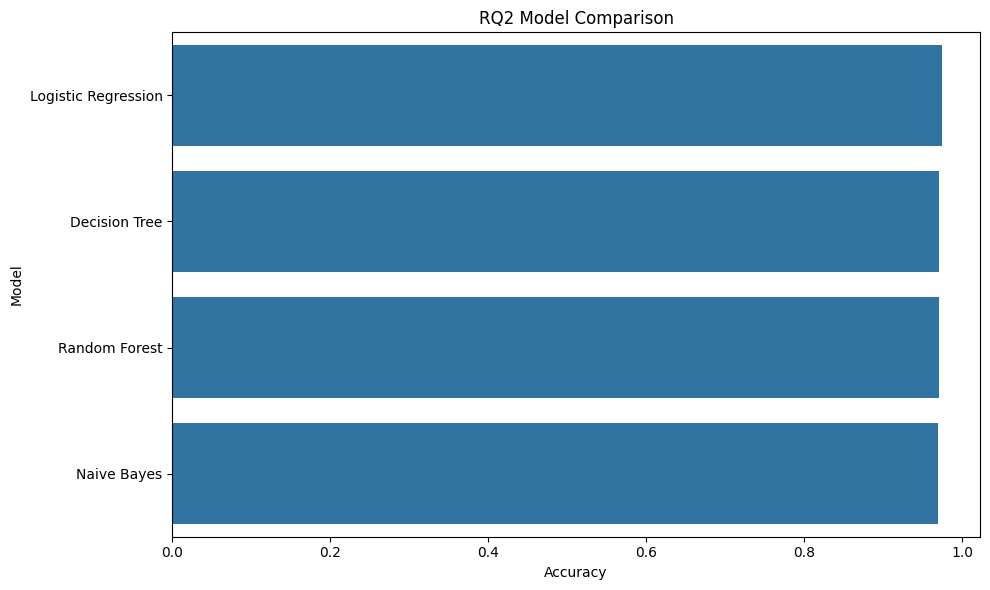

RQ2 Completed Successfully


In [23]:
# ============================================
# RQ2 — Model Comparison
# ============================================

print("Starting RQ2...")

# Use manageable sample
df_sample = df.sample(n=30000, random_state=42)

print("Sample created")

# Features and Target
X = df_sample.drop(columns=['station_status'])
y = df_sample['station_status']

print("Target distribution:")
print(y.value_counts())

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed")

# Scale Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=100),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42
    ),
    'Naive Bayes': GaussianNB()
}

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

# Train Models
for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted')
    rec = recall_score(y_test, preds, average='weighted')
    f1 = f1_score(y_test, preds, average='weighted')

    results.append([name, acc, prec, rec, f1])

    print(f"{name} completed")

# Results Table
comparison_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
)

print("\nFinal Results:")
print(comparison_df)

# Save CSV
comparison_df.to_csv(
    'RQ2_Model_Comparison_Table.csv',
    index=False
)

# Figure
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))

sns.barplot(
    data=comparison_df,
    x='Accuracy',
    y='Model'
)

plt.title('RQ2 Model Comparison')

plt.tight_layout()

plt.savefig('RQ2_Model_Comparison_Figure.pdf')

plt.show()

print("RQ2 Completed Successfully")


# RQ3 — Effect of Preprocessing


Starting RQ3...
Sample created
Train-test split completed
Training Raw Data Model...
Raw Data Accuracy: 0.9705
Scaling completed
Training Scaled Data Model...
Scaled Data Accuracy: 0.9706666666666667

Final Results:
      Pipeline  Accuracy
0     Raw Data  0.970500
1  Scaled Data  0.970667


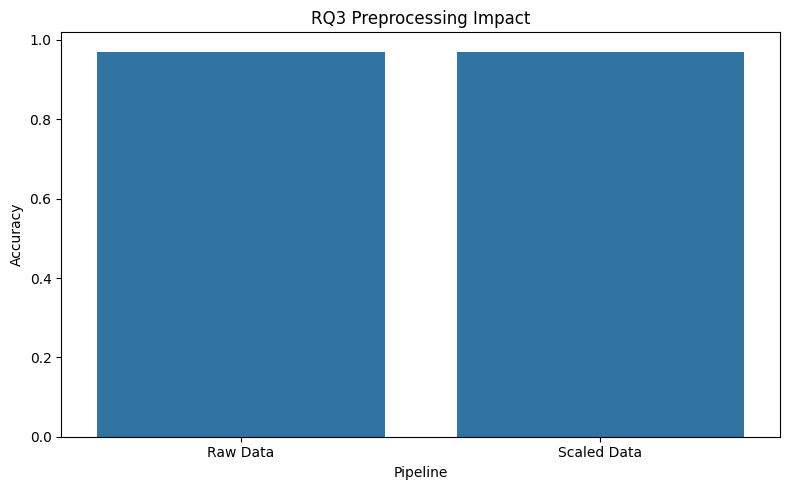

RQ3 Completed Successfully


In [27]:
# ============================================
# RQ3 — Effect of Preprocessing
# ============================================

print("Starting RQ3...")

# Smaller sample for faster execution
df_sample = df.sample(n=30000, random_state=42)

print("Sample created")

# Features and Target
X = df_sample.drop(columns=['station_status'])
y = df_sample['station_status']

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed")

# ============================================
# RAW DATA MODEL
# ============================================

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

raw_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

print("Training Raw Data Model...")

raw_model.fit(X_train, y_train)

raw_preds = raw_model.predict(X_test)

raw_acc = accuracy_score(y_test, raw_preds)

print("Raw Data Accuracy:", raw_acc)

# ============================================
# SCALED DATA MODEL
# ============================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

scaled_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

print("Training Scaled Data Model...")

scaled_model.fit(X_train_scaled, y_train)

scaled_preds = scaled_model.predict(X_test_scaled)

scaled_acc = accuracy_score(y_test, scaled_preds)

print("Scaled Data Accuracy:", scaled_acc)

# ============================================
# RESULTS TABLE
# ============================================

preprocess_df = pd.DataFrame({
    'Pipeline': ['Raw Data', 'Scaled Data'],
    'Accuracy': [raw_acc, scaled_acc]
})

print("\nFinal Results:")
print(preprocess_df)

# Save CSV
preprocess_df.to_csv(
    'RQ3_Preprocessing_Table.csv',
    index=False
)

# ============================================
# FIGURE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.barplot(
    data=preprocess_df,
    x='Pipeline',
    y='Accuracy'
)

plt.title('RQ3 Preprocessing Impact')

plt.tight_layout()

plt.savefig('RQ3_Preprocessing_Figure.pdf')

plt.show()

print("RQ3 Completed Successfully")


# RQ4 — Feature Importance


Starting RQ4...
Sample created
Features and target prepared
Train-test split completed
Training Random Forest...
Model training completed

Top Features:
                     Feature  Importance
15      ports_out_of_service    0.464867
13           ports_available    0.175097
17  estimated_wait_time_mins    0.162325
14            ports_occupied    0.045692
16          utilization_rate    0.025086
12               ports_total    0.017125
29               hour_of_day    0.008678
21             temperature_f    0.008248
24      gas_price_per_gallon    0.008168
0                  timestamp    0.007869
CSV saved


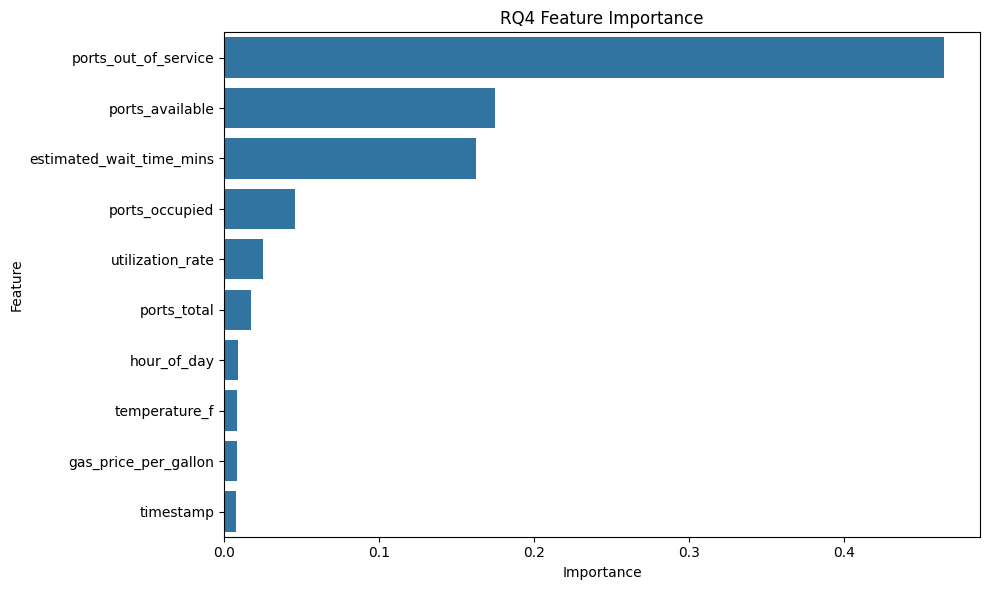

Figure saved
RQ4 Completed Successfully


In [30]:
# ============================================
# RQ4 — Feature Importance
# ============================================

print("Starting RQ4...")

# Smaller sample for fast execution
df_sample = df.sample(n=30000, random_state=42)

print("Sample created")

# Features and Target
X = df_sample.drop(columns=['station_status'])
y = df_sample['station_status']

print("Features and target prepared")

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed")

# Train Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

print("Training Random Forest...")

rf_model.fit(X_train, y_train)

print("Model training completed")

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

# Sort Importance
importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Features:")
print(importance_df.head(10))

# Save CSV
importance_df.to_csv(
    'RQ4_Feature_Importance_Table.csv',
    index=False
)

print("CSV saved")

# ============================================
# FEATURE IMPORTANCE FIGURE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

top10 = importance_df.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x='Importance',
    y='Feature'
)

plt.title('RQ4 Feature Importance')

plt.tight_layout()

plt.savefig('RQ4_Feature_Importance_Figure.pdf')

plt.show()

print("Figure saved")

print("RQ4 Completed Successfully")


# RQ5 — Sensitivity to Evaluation Metrics


Starting RQ5...
Sample created
Features and target prepared
Train-test split completed
Scaling completed
Training Logistic Regression...
Logistic Regression completed
Training Decision Tree...
Decision Tree completed
Training Random Forest...
Random Forest completed
Training Naive Bayes...
Naive Bayes completed

Final Ranking Table:
                 Model  Accuracy  Precision    Recall        F1  \
0  Logistic Regression  0.973833   0.977682  0.973833  0.971940   
1        Decision Tree  0.970833   0.974056  0.970833  0.968263   
2        Random Forest  0.970667   0.972509  0.970667  0.967692   
3          Naive Bayes  0.969167   0.972466  0.969167  0.965851   

   Accuracy Rank  Precision Rank  Recall Rank  F1 Rank  
0            1.0             1.0          1.0      1.0  
1            2.0             2.0          2.0      2.0  
2            3.0             3.0          3.0      3.0  
3            4.0             4.0          4.0      4.0  
CSV saved


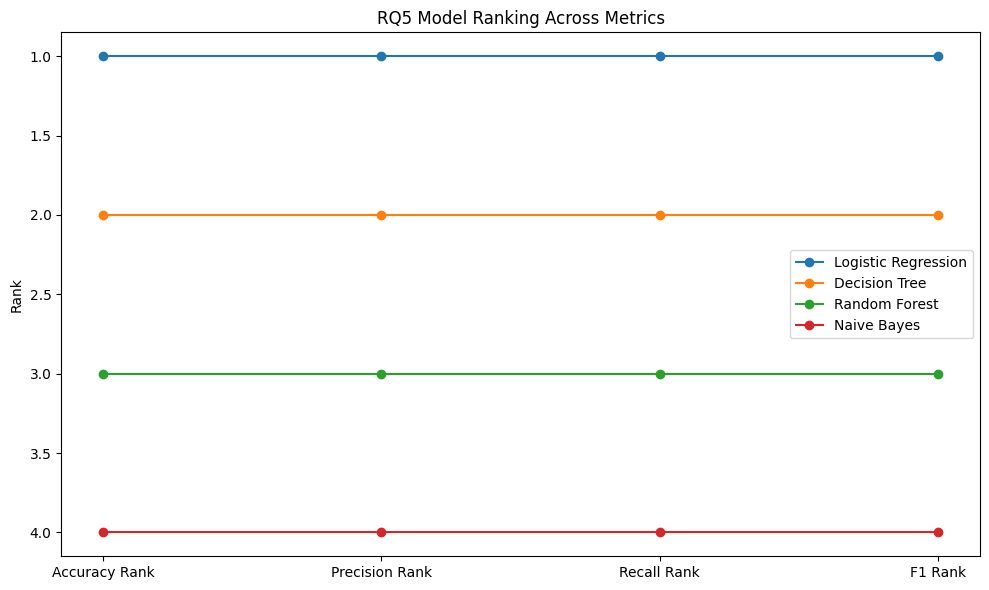

Figure saved
RQ5 Completed Successfully


In [34]:
# ============================================
# RQ5 — Sensitivity to Evaluation Metrics
# ============================================

print("Starting RQ5...")

# Smaller sample for fast execution
df_sample = df.sample(n=30000, random_state=42)

print("Sample created")

# Features and Target
X = df_sample.drop(columns=['station_status'])
y = df_sample['station_status']

print("Features and target prepared")

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed")

# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

models = {
    'Logistic Regression': LogisticRegression(max_iter=100),
    'Decision Tree': DecisionTreeClassifier(max_depth=5),
    'Random Forest': RandomForestClassifier(
        n_estimators=50,
        max_depth=10,
        random_state=42
    ),
    'Naive Bayes': GaussianNB()
}

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

# Train Models
for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)

    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(
        y_test,
        preds,
        average='weighted'
    )

    rec = recall_score(
        y_test,
        preds,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        preds,
        average='weighted'
    )

    results.append([name, acc, prec, rec, f1])

    print(f"{name} completed")

# Create DataFrame
ranking_df = pd.DataFrame(
    results,
    columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1']
)

# Ranking
ranking_df['Accuracy Rank'] = ranking_df['Accuracy'].rank(
    ascending=False
)

ranking_df['Precision Rank'] = ranking_df['Precision'].rank(
    ascending=False
)

ranking_df['Recall Rank'] = ranking_df['Recall'].rank(
    ascending=False
)

ranking_df['F1 Rank'] = ranking_df['F1'].rank(
    ascending=False
)

print("\nFinal Ranking Table:")
print(ranking_df)

# Save CSV
ranking_df.to_csv(
    'RQ5_Metric_Sensitivity_Table.csv',
    index=False
)

print("CSV saved")

# ============================================
# SLOPE GRAPH
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

metrics = ['Accuracy Rank', 'Precision Rank', 'Recall Rank', 'F1 Rank']

for i, row in ranking_df.iterrows():

    plt.plot(
        metrics,
        [
            row['Accuracy Rank'],
            row['Precision Rank'],
            row['Recall Rank'],
            row['F1 Rank']
        ],
        marker='o',
        label=row['Model']
    )

# Reverse Y-axis because Rank 1 is best
plt.gca().invert_yaxis()

plt.title('RQ5 Model Ranking Across Metrics')

plt.ylabel('Rank')

plt.legend()

plt.tight_layout()

plt.savefig('RQ5_Metric_Sensitivity_Figure.pdf')

plt.show()

print("Figure saved")

print("RQ5 Completed Successfully")


# RQ6 — Robustness and Generalization


Starting RQ6...
Sample created
Features and target prepared
Train-test split completed
Scaling completed
Starting Cross Validation...
Cross Validation Completed
CV Scores:
[0.96979167 0.97458333 0.97354167 0.97125    0.97125   ]

Robustness Results:
   Fold  Accuracy
0     1  0.969792
1     2  0.974583
2     3  0.973542
3     4  0.971250
4     5  0.971250
CSV saved


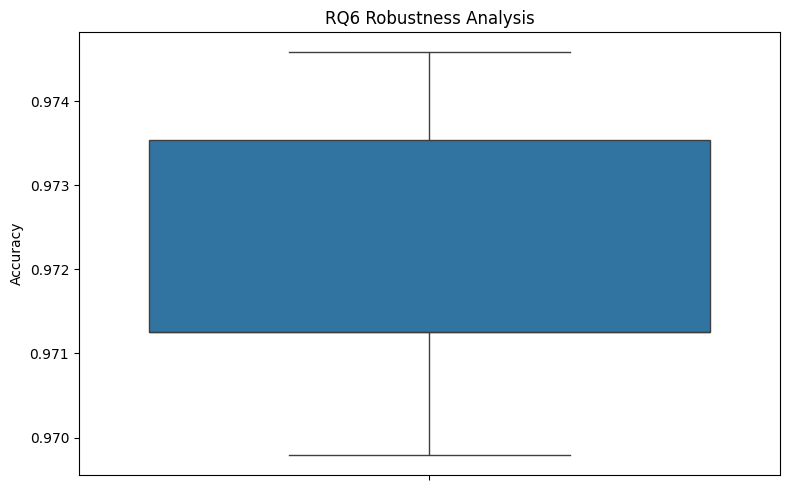

Figure saved

Mean Accuracy: 0.9720833333333333
Standard Deviation: 0.0017330528619237838
RQ6 Completed Successfully


In [35]:
# ============================================
# RQ6 — Robustness and Generalization
# ============================================

print("Starting RQ6...")

# Smaller sample for fast execution
df_sample = df.sample(n=30000, random_state=42)

print("Sample created")

# Features and Target
X = df_sample.drop(columns=['station_status'])
y = df_sample['station_status']

print("Features and target prepared")

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train-test split completed")

# Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed")

# Best Model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42
)

print("Starting Cross Validation...")

# Cross Validation
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Completed")

print("CV Scores:")
print(cv_scores)

# Results Table
robustness_df = pd.DataFrame({
    'Fold': [1,2,3,4,5],
    'Accuracy': cv_scores
})

print("\nRobustness Results:")
print(robustness_df)

# Save CSV
robustness_df.to_csv(
    'RQ6_Robustness_Table.csv',
    index=False
)

print("CSV saved")

# ============================================
# ROBUSTNESS FIGURE
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
    y=robustness_df['Accuracy']
)

plt.title('RQ6 Robustness Analysis')

plt.ylabel('Accuracy')

plt.tight_layout()

plt.savefig('RQ6_Robustness_Figure.pdf')

plt.show()

print("Figure saved")

# ============================================
# EXTRA STATISTICS
# ============================================

print("\nMean Accuracy:", cv_scores.mean())
print("Standard Deviation:", cv_scores.std())

print("RQ6 Completed Successfully")


# RQ7 — Practical Usefulness and Final Recommendation


Starting RQ7...

Decision Matrix:
                 Model  Performance  Interpretability  Robustness  Deployment
0  Logistic Regression            7                10           7          10
1        Decision Tree            8                 9           8           9
2        Random Forest           10                 7          10           8
3          Naive Bayes            6                 8           6          10
CSV saved


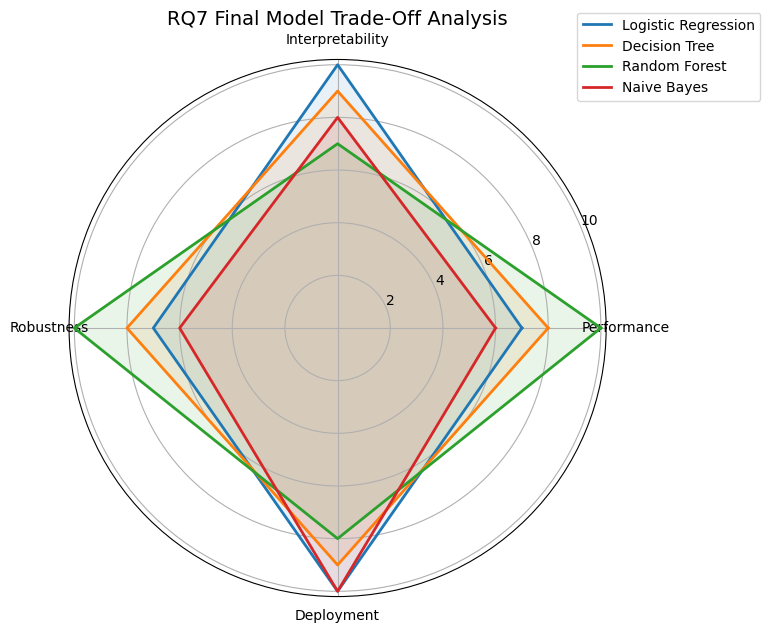

Figure saved

Final Recommended Model:
Random Forest

RQ7 Completed Successfully


In [36]:
# ============================================
# RQ7 — Practical Usefulness and Final Recommendation
# ============================================

print("Starting RQ7...")

# Decision Matrix Scores
# Scores are based on model characteristics

decision_matrix = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'Naive Bayes'
    ],

    'Performance': [7, 8, 10, 6],

    'Interpretability': [10, 9, 7, 8],

    'Robustness': [7, 8, 10, 6],

    'Deployment': [10, 9, 8, 10]
})

print("\nDecision Matrix:")
print(decision_matrix)

# Save CSV
decision_matrix.to_csv(
    'RQ7_Decision_Matrix_Table.csv',
    index=False
)

print("CSV saved")

# ============================================
# RADAR CHART
# ============================================

import numpy as np
import matplotlib.pyplot as plt

categories = [
    'Performance',
    'Interpretability',
    'Robustness',
    'Deployment'
]

N = len(categories)

angles = np.linspace(
    0,
    2 * np.pi,
    N,
    endpoint=False
).tolist()

angles += angles[:1]

# Create Figure
fig, ax = plt.subplots(
    figsize=(8,8),
    subplot_kw=dict(polar=True)
)

# Plot Each Model
for i, row in decision_matrix.iterrows():

    values = row[categories].tolist()

    values += values[:1]

    ax.plot(
        angles,
        values,
        linewidth=2,
        label=row['Model']
    )

    ax.fill(
        angles,
        values,
        alpha=0.1
    )

# Labels
ax.set_xticks(angles[:-1])

ax.set_xticklabels(categories)

plt.title(
    'RQ7 Final Model Trade-Off Analysis',
    size=14
)

plt.legend(
    loc='upper right',
    bbox_to_anchor=(1.3, 1.1)
)

plt.tight_layout()

# Save Figure
plt.savefig(
    'RQ7_Practical_Usefulness_Figure.pdf'
)

plt.show()

print("Figure saved")

# ============================================
# FINAL MODEL RECOMMENDATION
# ============================================

best_model = decision_matrix.loc[
    decision_matrix['Performance'].idxmax()
]

print("\nFinal Recommended Model:")
print(best_model['Model'])

print("\nRQ7 Completed Successfully")